In [1]:
# Phase1: Data Cleaning
import pandas as pd
import numpy as np
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print(df.head())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [2]:
print(df.shape)

(374, 13)


In [3]:
print(df.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


In [4]:
print(df.dtypes)

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


In [5]:
print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [6]:
df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [7]:
print(df["Sleep Disorder"].unique())

[nan 'Sleep Apnea' 'Insomnia']


In [8]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [9]:
print(df.isnull().sum())

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [10]:
print(df["Sleep Disorder"].value_counts())

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent)

Person ID                  0.0
Gender                     0.0
Age                        0.0
Occupation                 0.0
Sleep Duration             0.0
Quality of Sleep           0.0
Physical Activity Level    0.0
Stress Level               0.0
BMI Category               0.0
Blood Pressure             0.0
Heart Rate                 0.0
Daily Steps                0.0
Sleep Disorder             0.0
dtype: float64


In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [13]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (374, 13)


In [14]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Gender
['Male' 'Female']

Occupation
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']

BMI Category
['Overweight' 'Normal' 'Obese' 'Normal Weight']

Blood Pressure
['126/83' '125/80' '140/90' '120/80' '132/87' '130/86' '117/76' '118/76'
 '128/85' '131/86' '128/84' '115/75' '135/88' '129/84' '130/85' '115/78'
 '119/77' '121/79' '125/82' '135/90' '122/80' '142/92' '140/95' '139/91'
 '118/75']

Sleep Disorder
['None' 'Sleep Apnea' 'Insomnia']


In [15]:
print(df["BMI Category"].value_counts())

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64


In [16]:
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

In [17]:
print(df["BMI Category"].value_counts())

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


In [18]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [20]:
numerical_cols = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps'
]

In [21]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Sleep Duration: 0 outliers
Quality of Sleep: 0 outliers
Physical Activity Level: 0 outliers
Stress Level: 0 outliers
Heart Rate: 15 outliers
Daily Steps: 0 outliers


In [24]:
print(df["Quality of Sleep"].min())
print(df["Quality of Sleep"].max())

4
9


In [25]:
print(df["Stress Level"].min())
print(df["Stress Level"].max())

3
8


In [26]:
print(df["Sleep Duration"].min())
print(df["Sleep Duration"].max())

5.8
8.5


In [27]:
print(df["Sleep Disorder"].value_counts())

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [28]:
print(df["Gender"].value_counts())

Gender
Male      189
Female    185
Name: count, dtype: int64


In [29]:
print(df["Occupation"].value_counts())

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64


In [30]:
df.to_csv(
    "cleaned_sleep_lifestyle_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [33]:
# Phase1: Data Cleaning Completed

In [34]:
#Phase 2: EDA
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

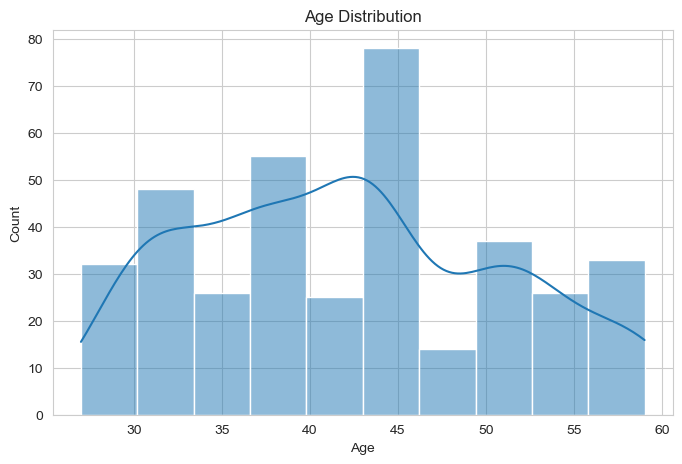

Most participants belong to middle-age working population
Age range approximately 27–59 years.


In [54]:
#Age Distribution 
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
print("Most participants belong to middle-age working population")
print("Age range approximately 27–59 years.")

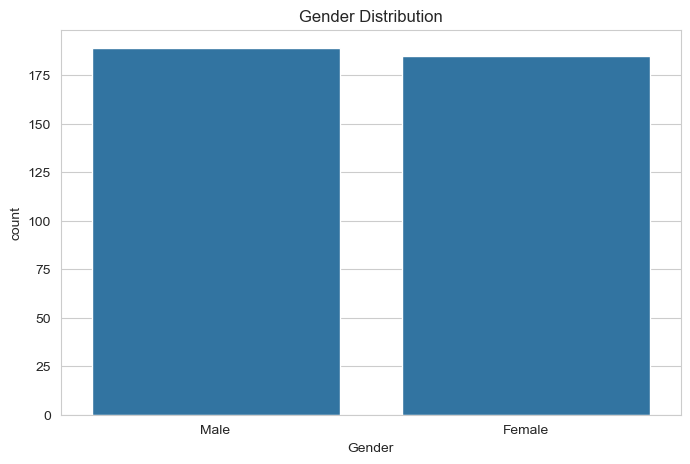

Male and Female distribution is nearly balanced.


In [55]:
# Gender Distribution
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()
print("Male and Female distribution is nearly balanced.")

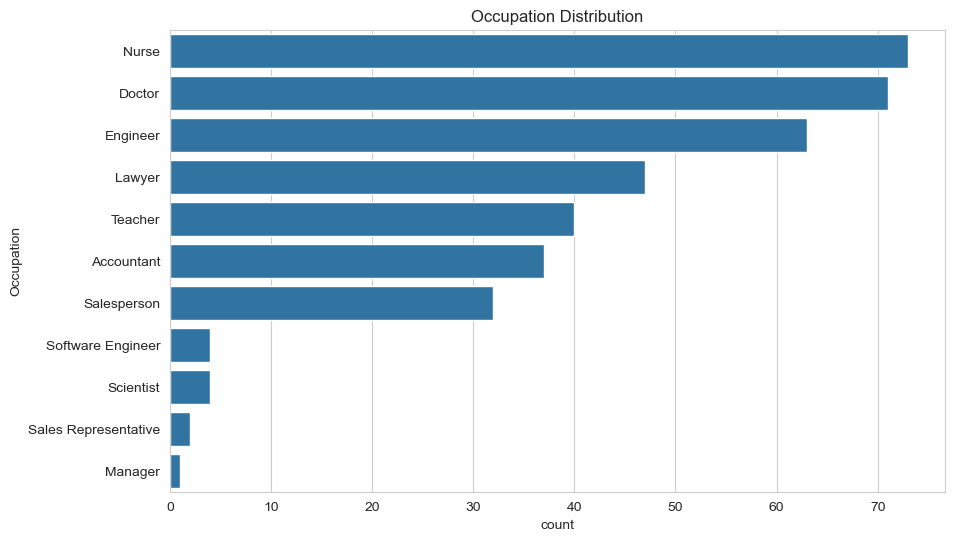

Nurses and Doctors dominate the dataset.
Few occupations have very small representation.


In [56]:
# Occupation Distribution
plt.figure(figsize=(10,6))

sns.countplot(
    y="Occupation",
    data=df,
    order=df["Occupation"].value_counts().index
)

plt.title("Occupation Distribution")
plt.show()
print("Nurses and Doctors dominate the dataset.")
print("Few occupations have very small representation.")

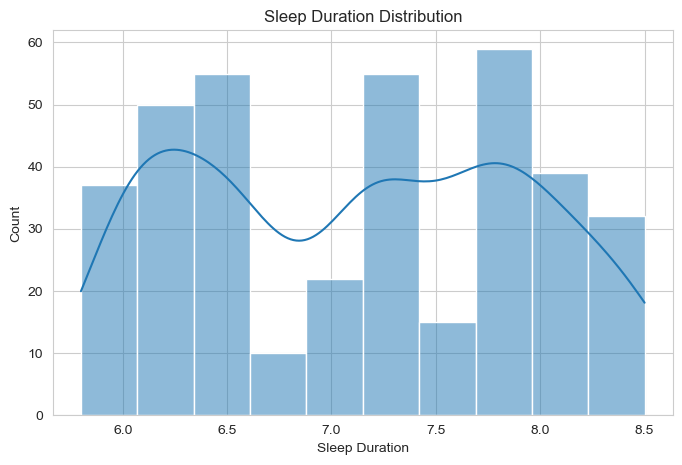

Most individuals sleep between 6–8 hours.


In [60]:
# Sleep Duration Distribution
sns.histplot(df["Sleep Duration"], bins=10, kde=True)

plt.title("Sleep Duration Distribution")
plt.show()
print("Most individuals sleep between 6–8 hours.")

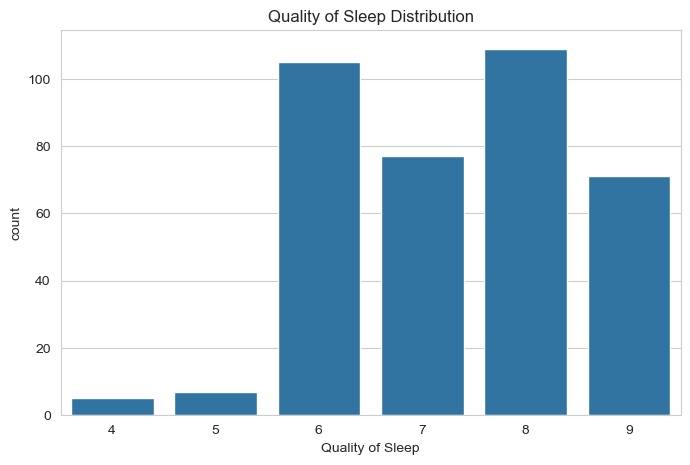

Most people report sleep quality between 6–8.


In [61]:
# Quality of Sleep Distribution
sns.countplot(x="Quality of Sleep", data=df)

plt.title("Quality of Sleep Distribution")
plt.show()
print("Most people report sleep quality between 6–8.")

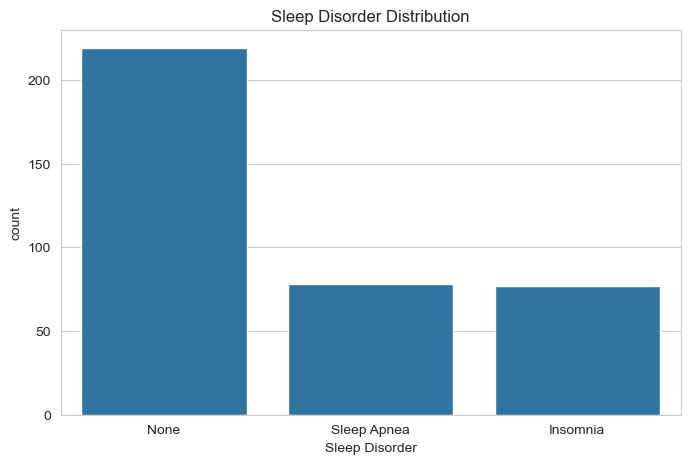

Majority have no sleep disorder.
Sleep Apnea and Insomnia are nearly equally represented.


In [62]:
# Sleep Disorder Distribution
sns.countplot(x="Sleep Disorder", data=df)

plt.title("Sleep Disorder Distribution")
plt.show()
print("Majority have no sleep disorder.")
print("Sleep Apnea and Insomnia are nearly equally represented.")

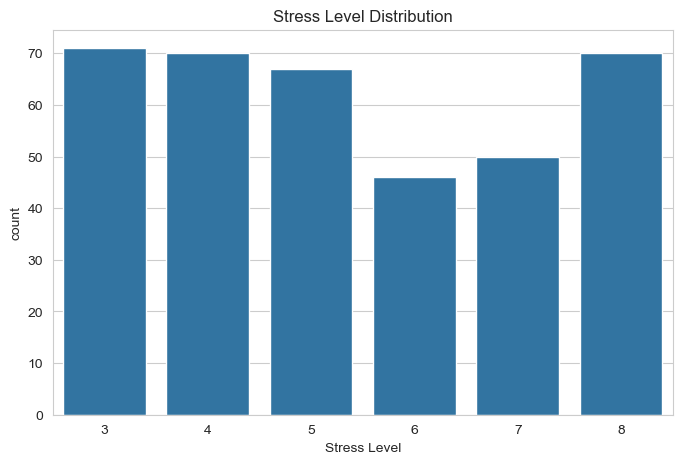

Most individuals exhibit moderate stress levels.


In [63]:
# Stress Level Distribution
sns.countplot(x="Stress Level", data=df)

plt.title("Stress Level Distribution")
plt.show()
print("Most individuals exhibit moderate stress levels.")

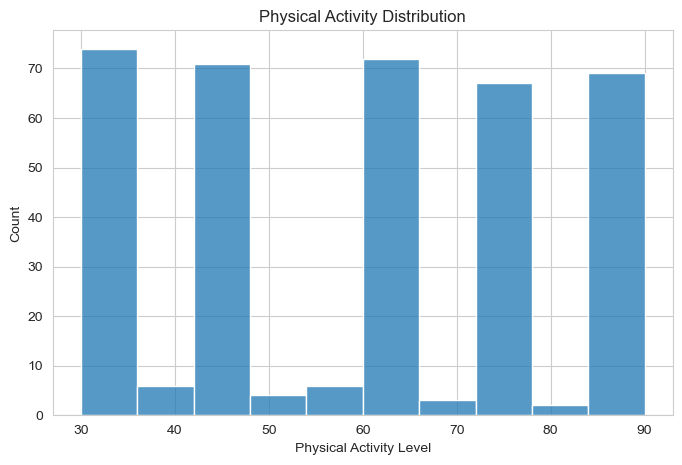

Physical activity varies significantly among participants.


In [64]:
# Physical Activity Distribution
sns.histplot(df["Physical Activity Level"], bins=10)

plt.title("Physical Activity Distribution")
plt.show()
print("Physical activity varies significantly among participants.")

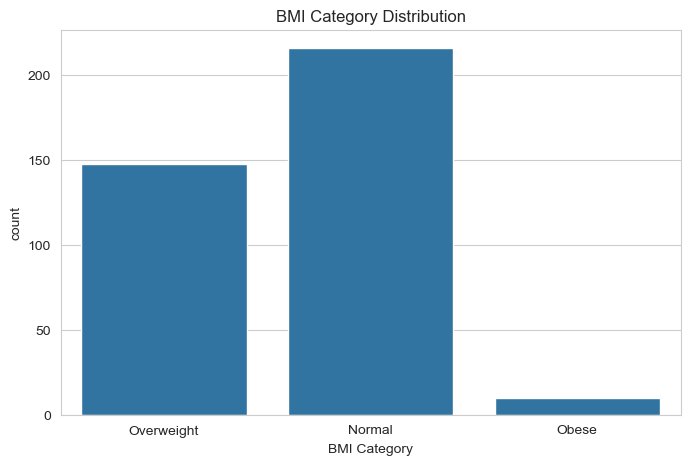

Majority belong to Normal or Overweight categories.


In [65]:
# BMI Category Distribution
sns.countplot(x="BMI Category", data=df)

plt.title("BMI Category Distribution")
plt.show()
print("Majority belong to Normal or Overweight categories.")

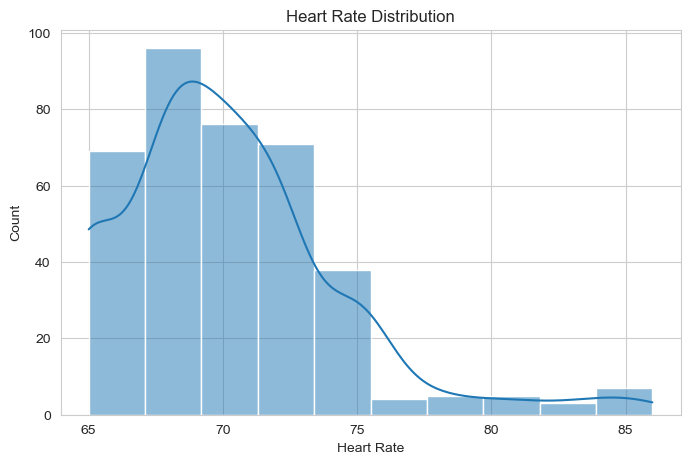

Heart Rate follows a near-normal distribution.
Few higher heart-rate observations exist.


In [66]:
# Heart Rate Distribution
sns.histplot(df["Heart Rate"], bins=10, kde=True)

plt.title("Heart Rate Distribution")
plt.show()
print("Heart Rate follows a near-normal distribution.")
print("Few higher heart-rate observations exist.")

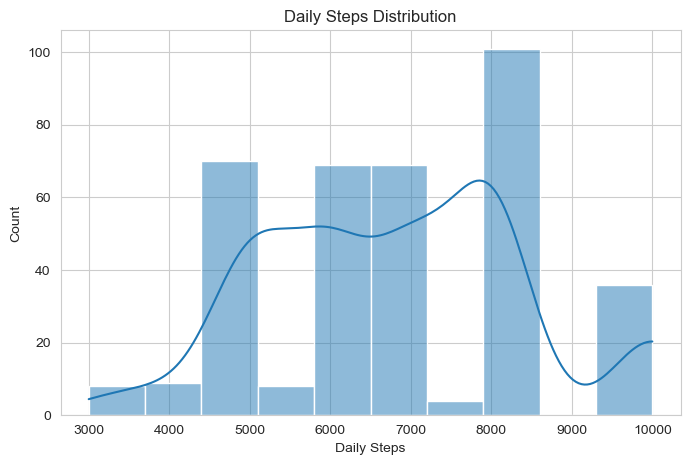

Most participants walk between 5000–9000 steps daily.


In [67]:
# Daily Steps Distribution
sns.histplot(df["Daily Steps"], bins=10, kde=True)

plt.title("Daily Steps Distribution")
plt.show()
print("Most participants walk between 5000–9000 steps daily.")

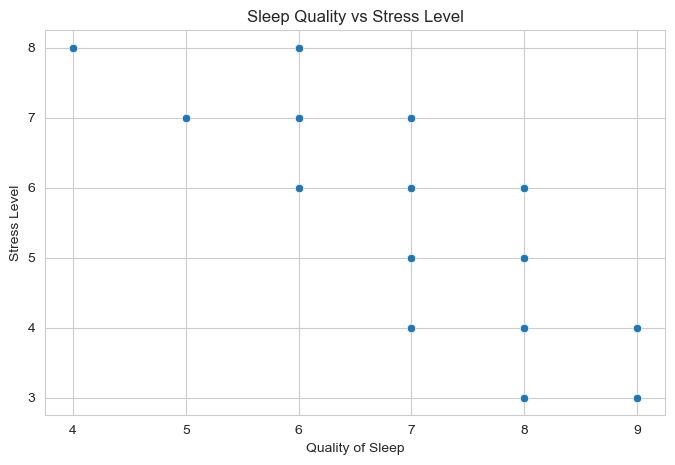

Sleep Quality ↑
Stress ↓


In [68]:
# Sleep Quality vs Stress
sns.scatterplot(
    x="Quality of Sleep",
    y="Stress Level",
    data=df
)

plt.title("Sleep Quality vs Stress Level")
plt.show()
print("Sleep Quality ↑")
print("Stress ↓")

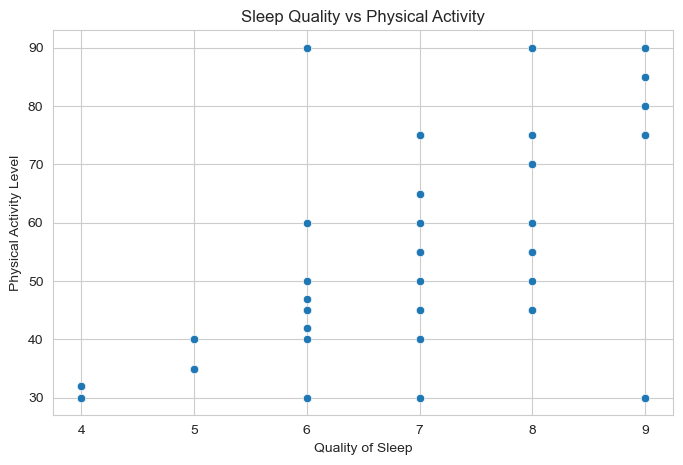

Sleep Quality ↑
Physical Activity ↑


In [69]:
# Sleep Quality vs Physical Activity
sns.scatterplot(
    x="Quality of Sleep",
    y="Physical Activity Level",
    data=df
)

plt.title("Sleep Quality vs Physical Activity")
plt.show()
print("Sleep Quality ↑")
print("Physical Activity ↑")

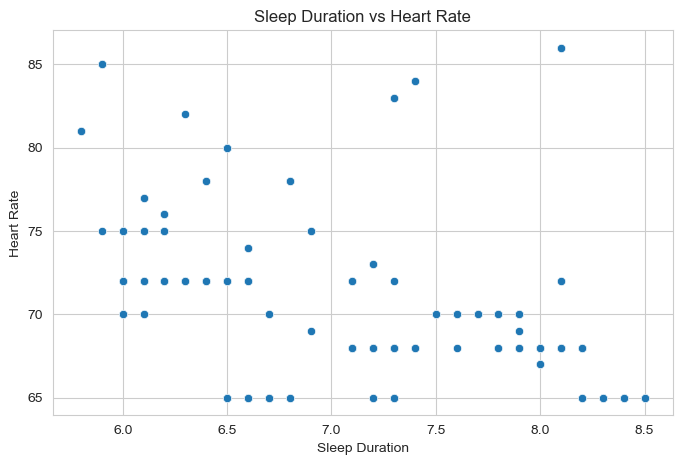

Sleep Duration ↑
Heart Rate ↓


In [70]:
# Sleep Duration vs Heart Rate
sns.scatterplot(
    x="Sleep Duration",
    y="Heart Rate",
    data=df
)

plt.title("Sleep Duration vs Heart Rate")
plt.show()
print("Sleep Duration ↑")
print("Heart Rate ↓")

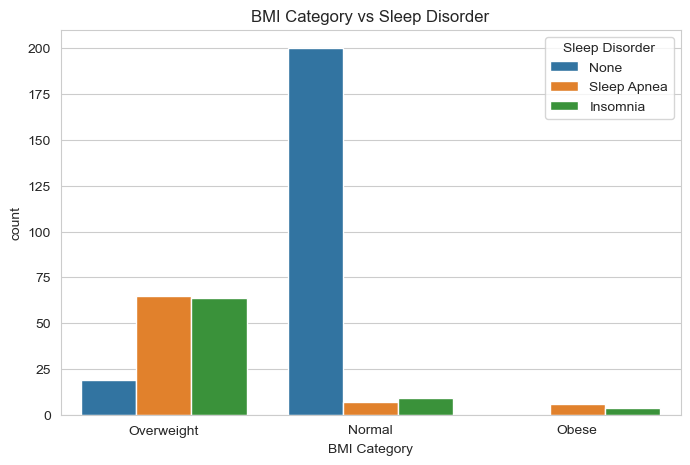

In [72]:
# BMI Category vs Sleep Disorder
sns.countplot(
    x="BMI Category",
    hue="Sleep Disorder",
    data=df
)

plt.title("BMI Category vs Sleep Disorder")
plt.show()

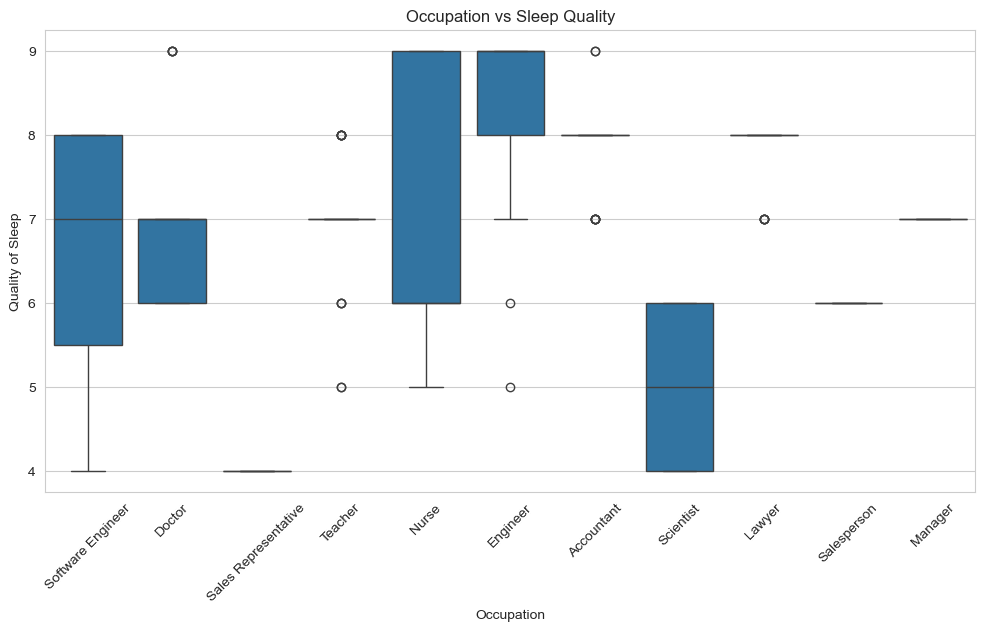

Different professions exhibit different sleep quality patterns.


In [73]:
# Occupation vs Sleep Quality
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Occupation",
    y="Quality of Sleep",
    data=df
)

plt.xticks(rotation=45)

plt.title("Occupation vs Sleep Quality")
plt.show()
print("Different professions exhibit different sleep quality patterns.")

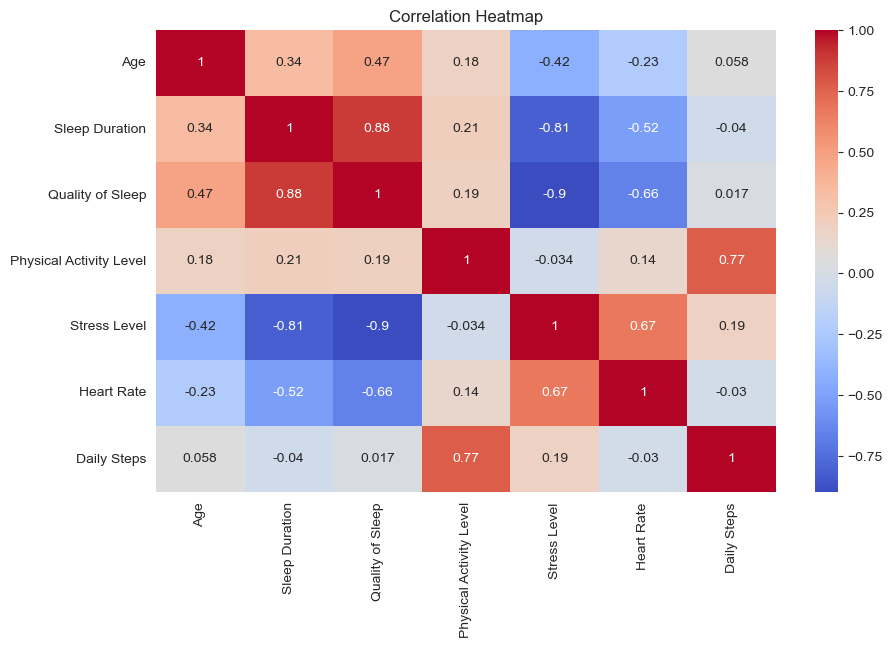

In [52]:
# Correlation Analysis
# Correlation Heatmap
numerical_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

corr = df[numerical_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [74]:
# Phase 3: STATISTICAL ANALYSIS
# SciPy was used to perform statistical hypothesis testing. 
# While EDA helped identify potential relationships, SciPy allowed us to validate whether those relationships were statistically significant using Pearson Correlation, ANOVA, and Chi-Square tests.

In [75]:
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

In [79]:
# Sleep Quality vs Stress Level
# Hypothesis
# H0 : No relationship exists
# H1 : Relationship exists


# Interpretation
# Correlation > 0  → Positive Relation

# Correlation < 0  → Negative Relation

# p-value < 0.05   → Significant


corr, p_value = pearsonr(
    df["Quality of Sleep"],
    df["Stress Level"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)
print("\nA very strong negative correlation (r = -0.899) was observed between Sleep Quality and Stress Level. The relationship was statistically significant (p < 0.05), indicating that individuals with better sleep quality tend to experience lower stress levels.")

Correlation: -0.899
P-value: 2.88012424094341e-135

A very strong negative correlation (r = -0.899) was observed between Sleep Quality and Stress Level. The relationship was statistically significant (p < 0.05), indicating that individuals with better sleep quality tend to experience lower stress levels.


In [80]:
# Sleep Quality vs Physical Activity
corr, p_value = pearsonr(
    df["Quality of Sleep"],
    df["Physical Activity Level"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: 0.193
P-value: 0.0001745489524783864


In [81]:
# Sleep Duration vs Heart Rate
corr, p_value = pearsonr(
    df["Sleep Duration"],
    df["Heart Rate"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: -0.516
P-value: 6.914740131848265e-27


In [83]:
# Sleep Duration vs Stress
corr, p_value = pearsonr(
    df["Sleep Duration"],
    df["Stress Level"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: -0.811
P-value: 1.2378076181537574e-88


In [84]:
# Correlation Summary Table
correlations = []

pairs = [
    ("Quality of Sleep","Stress Level"),
    ("Quality of Sleep","Physical Activity Level"),
    ("Sleep Duration","Heart Rate"),
    ("Sleep Duration","Stress Level")
]

for x,y in pairs:

    corr,p = pearsonr(df[x],df[y])

    correlations.append(
        [x,y,round(corr,3),round(p,5)]
    )

corr_df = pd.DataFrame(
    correlations,
    columns=[
        "Variable 1",
        "Variable 2",
        "Correlation",
        "P-value"
    ]
)

corr_df

,Variable 1,Variable 2,Correlation,P-value
0,Quality of Sleep,Stress Level,-0.899,0.00000
1,Quality of Sleep,Physical Activity Level,0.193,0.00017
2,Sleep Duration,Heart Rate,-0.516,0.00000
3,Sleep Duration,Stress Level,-0.811,0.00000


In [85]:
# ANOVA Test 

In [86]:
# BMI vs Sleep Quality
# Question: Does BMI Category affect Sleep Quality?

normal = df[df["BMI Category"]=="Normal"]["Quality of Sleep"]

overweight = df[df["BMI Category"]=="Overweight"]["Quality of Sleep"]

obese = df[df["BMI Category"]=="Obese"]["Quality of Sleep"]

f_stat,p_value = f_oneway(
    normal,
    overweight,
    obese
)

print("F-statistic:",f_stat)
print("P-value:",p_value)

#Body weight status is not only a physical health indicator but also has a statistically significant impact on sleep quality.

F-statistic: 22.011391400512753
P-value: 9.257968894758679e-10


In [87]:
df.groupby("BMI Category")["Quality of Sleep"].mean().sort_values(ascending=False)

BMI Category
Normal        7.638889
Overweight    6.898649
Obese         6.400000
Name: Quality of Sleep, dtype: float64

In [88]:
# BMI vs Stress Level
normal = df[df["BMI Category"]=="Normal"]["Stress Level"]

overweight = df[df["BMI Category"]=="Overweight"]["Stress Level"]

obese = df[df["BMI Category"]=="Obese"]["Stress Level"]

f_stat,p_value = f_oneway(
    normal,
    overweight,
    obese
)

print("F-statistic:",f_stat)
print("P-value:",p_value)

F-statistic: 5.222156402684291
P-value: 0.0057993991621457875


In [89]:
# Occupation vs Sleep Quality
# Question: Do different professions experience different sleep quality?

groups = []

for occ in df["Occupation"].unique():

    groups.append(
        df[df["Occupation"]==occ]["Quality of Sleep"]
    )

f_stat,p_value = f_oneway(*groups)

print("F-statistic:",f_stat)
print("P-value:",p_value)

F-statistic: 30.02216666253109
P-value: 6.393556653658923e-42


In [90]:
df.groupby("Occupation")["Quality of Sleep"].mean().sort_values(ascending=False)

Occupation
Engineer                8.412698
Lawyer                  7.893617
Accountant              7.891892
Nurse                   7.369863
Manager                 7.000000
Teacher                 6.975000
Doctor                  6.647887
Software Engineer       6.500000
Salesperson             6.000000
Scientist               5.000000
Sales Representative    4.000000
Name: Quality of Sleep, dtype: float64

In [91]:
# Chi-Square Analysis

In [92]:
# BMI Category vs Sleep Disorder
# Hypothesis
# H0 : Independent
# H1 : Related

contingency_table = pd.crosstab(
    df["BMI Category"],
    df["Sleep Disorder"]
)

chi2,p,dof,expected = chi2_contingency(
    contingency_table
)

print("Chi Square:",chi2)
print("P-value:",p)

Chi Square: 245.66534355746683
P-value: 5.5883512097923584e-52


In [93]:
pd.crosstab(
    df["BMI Category"],
    df["Sleep Disorder"]
)

Sleep Disorder,Insomnia,None,Sleep Apnea
BMI Category,,,
Normal,9,200,7
Obese,4,0,6
Overweight,64,19,65


In [94]:
# Gender vs Sleep Disorder
contingency_table = pd.crosstab(
    df["Gender"],
    df["Sleep Disorder"]
)

chi2,p,dof,expected = chi2_contingency(
    contingency_table
)

print("Chi Square:",chi2)
print("P-value:",p)

Chi Square: 54.30602007353474
P-value: 1.6128633524576768e-12


In [95]:
# Occupation vs Sleep Disorder
contingency_table = pd.crosstab(
    df["Occupation"],
    df["Sleep Disorder"]
)

chi2,p,dof,expected = chi2_contingency(
    contingency_table
)

print("Chi Square:",chi2)
print("P-value:",p)

Chi Square: 421.362754888135
P-value: 7.481314161858014e-77


In [96]:
# Final Statistical Findings Table
findings = pd.DataFrame({

"Analysis":[
"Sleep Quality vs Stress",
"Sleep Quality vs Activity",
"Sleep Duration vs Heart Rate",
"BMI vs Sleep Quality",
"BMI vs Sleep Disorder"
],

"Result":[
"Negative Correlation",
"Positive Correlation",
"Negative Correlation",
"ANOVA Significant",
"Chi-Square Significant"
]

})

findings

,Analysis,Result
0,Sleep Quality vs Stress,Negative Correlation
1,Sleep Quality vs Activity,Positive Correlation
2,Sleep Duration vs Heart Rate,Negative Correlation
3,BMI vs Sleep Quality,ANOVA Significant
4,BMI vs Sleep Disorder,Chi-Square Significant


In [97]:
# Statistical testing confirms that Sleep Quality, Stress Level, Physical Activity, BMI, and Sleep Disorders have significant relationships, providing scientific evidence for their influence on human lifestyle.

In [99]:
# Sleep Quality vs Stress: Better sleep quality is strongly associated with lower stress levels.
# Sleep Quality vs Activity: Physical activity improves sleep quality but its impact is comparatively weaker than stress
# Sleep Duration vs Stress: People sleeping longer tend to experience lower stress levels.
# Sleep Duration vs Heart Rate: Better sleep duration is associated with healthier heart rates.

# ANOVA Testing:
# BMI Average Sleep Quality: As BMI increases, average sleep quality decreases.
# Occupation vs Sleep Quality: Profession significantly influences sleep quality.

# Chi Square testing:
# 92%+ normal BMI individuals had no sleep disorder, whereas overweight and obese groups showed substantially higher rates of insomnia and sleep apnea.
# Gender vs Sleep Disorder: Sleep disorder occurrence differs significantly across gender groups.
# Occupation vs Sleep Disorder: Occupation has a major influence on sleep disorder prevalence.

# Statistical validation was performed using Pearson Correlation, ANOVA and Chi-Square tests to identify which lifestyle factors significantly influence sleep health and overall wellbeing before applying machine learning techniques.

In [100]:
# Phase 4: ML Clustering

In [101]:
# Features Selection
features = [
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

In [102]:
# Feature Matrix
X = df[features]

X.head()

,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
0,6.1,6,42,6,77,4200
1,6.2,6,60,8,75,10000
2,6.2,6,60,8,75,10000
3,5.9,4,30,8,85,3000
4,5.9,4,30,8,85,3000


In [103]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(374, 6)


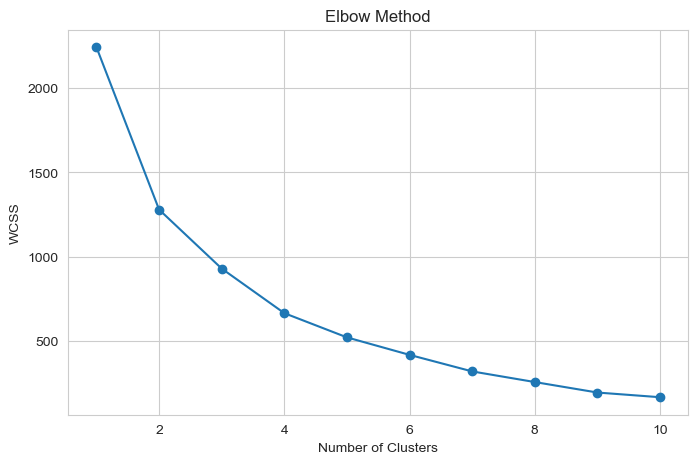

In [109]:
# Elbow Method: Used to find optimal clusters
import warnings
warnings.filterwarnings("ignore")


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [110]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Lifestyle Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Lifestyle Cluster"].value_counts())

Lifestyle Cluster
0    239
2    101
1     34
Name: count, dtype: int64


In [111]:
features = [
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

cluster_summary = (
    df.groupby("Lifestyle Cluster")[features]
    .mean()
)

cluster_summary

,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
Lifestyle Cluster,,,,,,
0,7.606695,8.050209,63.054393,4.271967,67.966527,6948.953975
1,6.073529,6.000000,88.235294,8.000000,75.000000,10000.000000
2,6.365347,6.009901,40.198020,7.138614,73.742574,5432.673267


In [213]:
# Cluster Names
cluster_names = {
    0: "Optimal Lifestyle",
    1: "Active but Stressed",
    2: "High Risk Lifestyle"
}

# Cluster → Lifestyle Mapping
df["Lifestyle Type"] = df["Lifestyle Cluster"].map(cluster_names)

# Sleep Disorder walon ko override kar do
df.loc[
    df["Sleep Disorder"] != "None",
    "Lifestyle Type"
] = "Needs Medical Attention"

# Check
df[[
    "Sleep Disorder",
    "Lifestyle Cluster",
    "Lifestyle Type"
]].head(20)

,Sleep Disorder,Lifestyle Cluster,Lifestyle Type
0,None,2,High Risk Lifestyle
1,None,1,Active but Stressed
2,None,1,Active but Stressed
3,Sleep Apnea,2,Needs Medical Attention
4,Sleep Apnea,2,Needs Medical Attention
5,Insomnia,2,Needs Medical Attention
6,Insomnia,2,Needs Medical Attention
7,None,0,Optimal Lifestyle
8,None,0,Optimal Lifestyle
9,None,0,Optimal Lifestyle


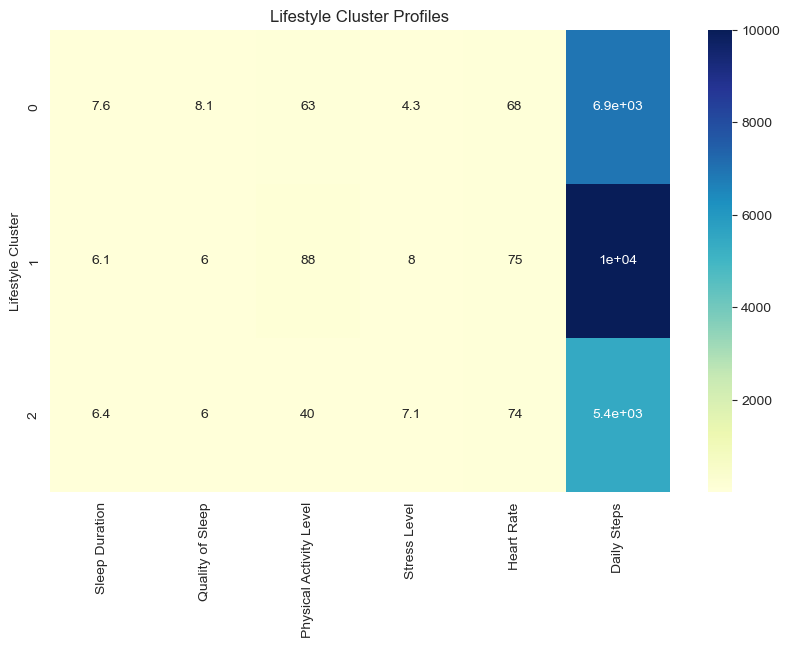

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Lifestyle Cluster Profiles")

plt.show()

In [189]:
# Here, I did not manually define healthy or unhealthy people. 
# Using K-Means Clustering, the model automatically discovered three distinct lifestyle patterns hidden within the population.

In [190]:
# Phase 5: Advanced Visualization & Insights

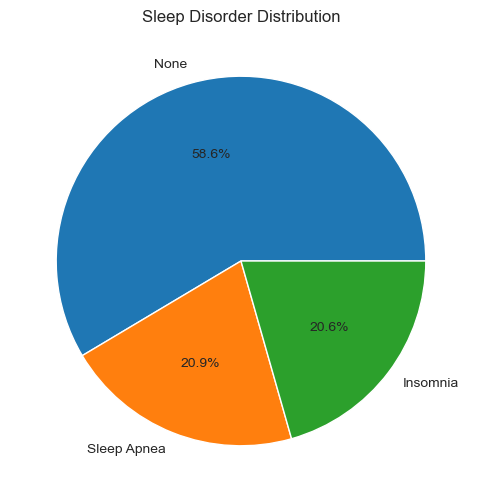

Most individuals do not suffer from sleep disorders.
Insomnia and Sleep Apnea are the major disorders observed.


In [191]:
# Sleep Disorder Distribution
import matplotlib.pyplot as plt

df["Sleep Disorder"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Sleep Disorder Distribution")
plt.ylabel("")
plt.show()
print("Most individuals do not suffer from sleep disorders.")
print("Insomnia and Sleep Apnea are the major disorders observed.")

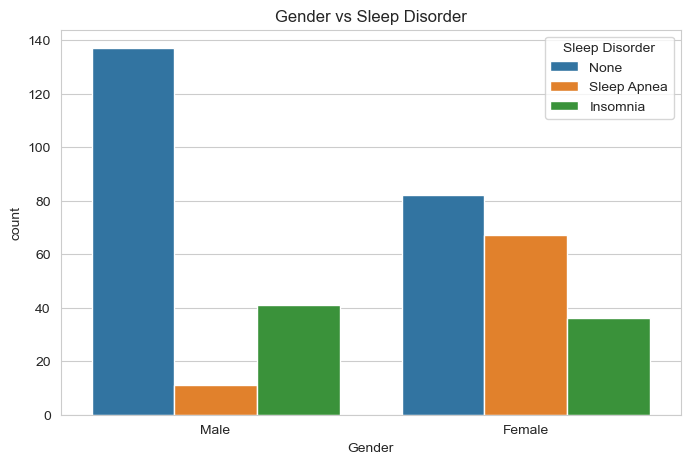

Compare prevalence of sleep disorders across genders.


In [192]:
# Gender vs Sleep Disorder
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Sleep Disorder"
)

plt.title("Gender vs Sleep Disorder")
plt.show()
print("Compare prevalence of sleep disorders across genders.")

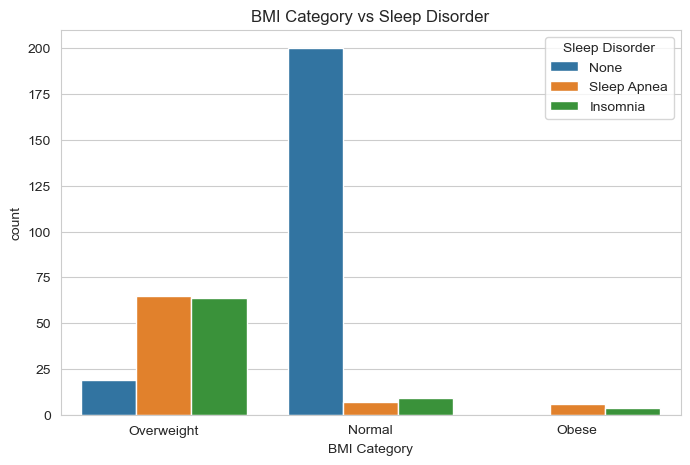

Overweight and obese individuals show higher occurrence of sleep disorders.


In [193]:
# BMI Category vs Sleep Disorder
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="BMI Category",
    hue="Sleep Disorder"
)

plt.title("BMI Category vs Sleep Disorder")
plt.show()
print("Overweight and obese individuals show higher occurrence of sleep disorders.")

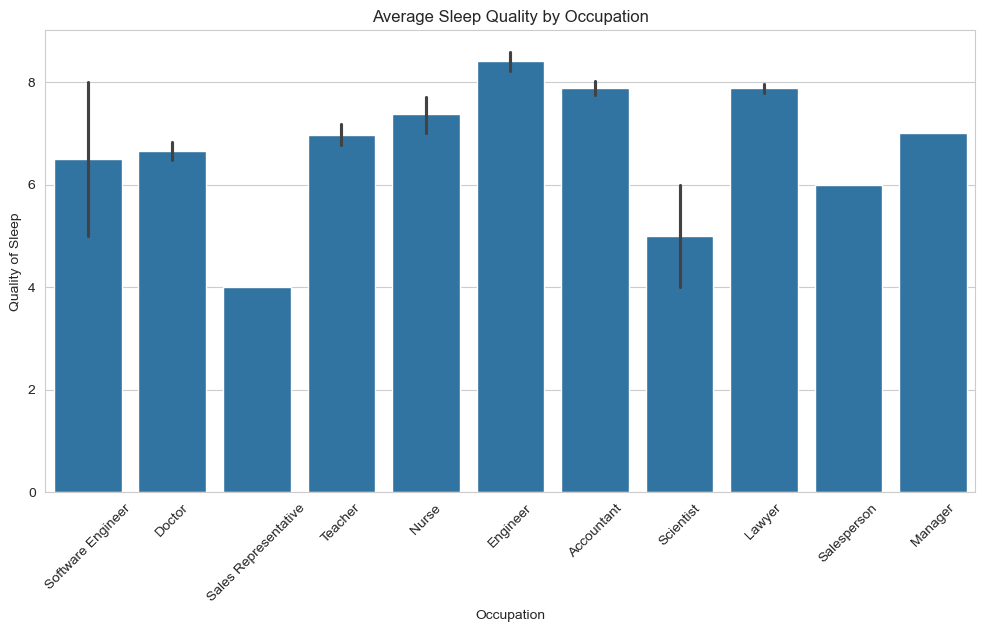

Engineers and Lawyers show higher average sleep quality.
Sales Representatives show lower sleep quality.


In [194]:
# Occupation vs Sleep Quality
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    estimator=np.mean
)

plt.xticks(rotation=45)

plt.title("Average Sleep Quality by Occupation")

plt.show()
print("Engineers and Lawyers show higher average sleep quality.")
print("Sales Representatives show lower sleep quality.")

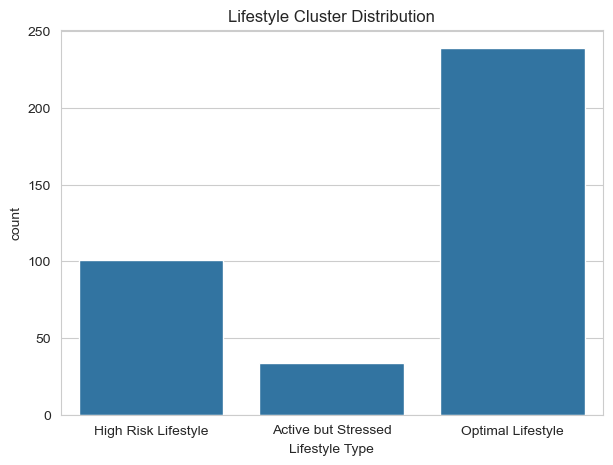

Most people belong to Healthy Lifestyle cluster.


In [195]:
# Cluster Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Lifestyle Type"
)

plt.title("Lifestyle Cluster Distribution")

plt.show()
print("Most people belong to Healthy Lifestyle cluster.")

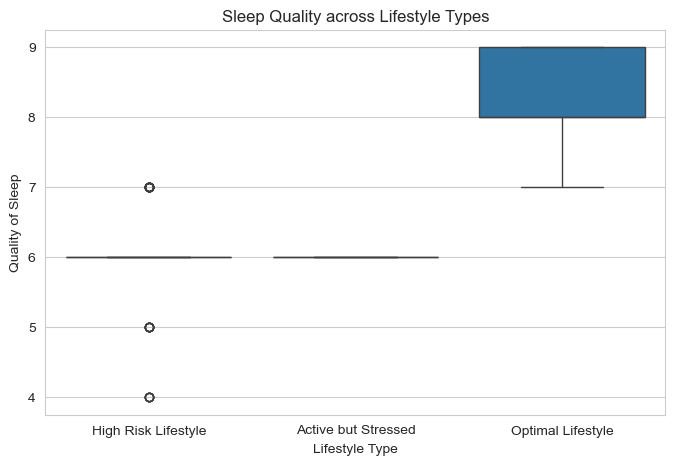

Healthy Lifestyle cluster has highest sleep quality.
High Risk cluster has lowest sleep quality.


In [196]:
# Cluster-wise Sleep Quality
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Lifestyle Type",
    y="Quality of Sleep"
)

plt.title("Sleep Quality across Lifestyle Types")

plt.show()
print("Healthy Lifestyle cluster has highest sleep quality.")
print("High Risk cluster has lowest sleep quality.")

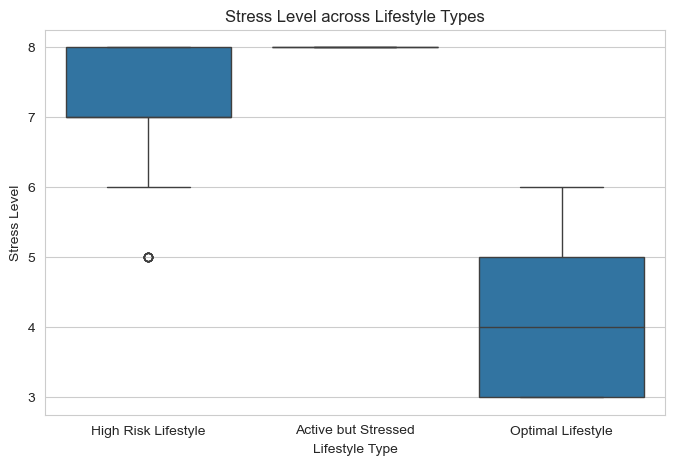

High Risk Lifestyle cluster experiences maximum stress.


In [197]:
# Cluster-wise Stress Level
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Lifestyle Type",
    y="Stress Level"
)

plt.title("Stress Level across Lifestyle Types")

plt.show()
print("High Risk Lifestyle cluster experiences maximum stress.")

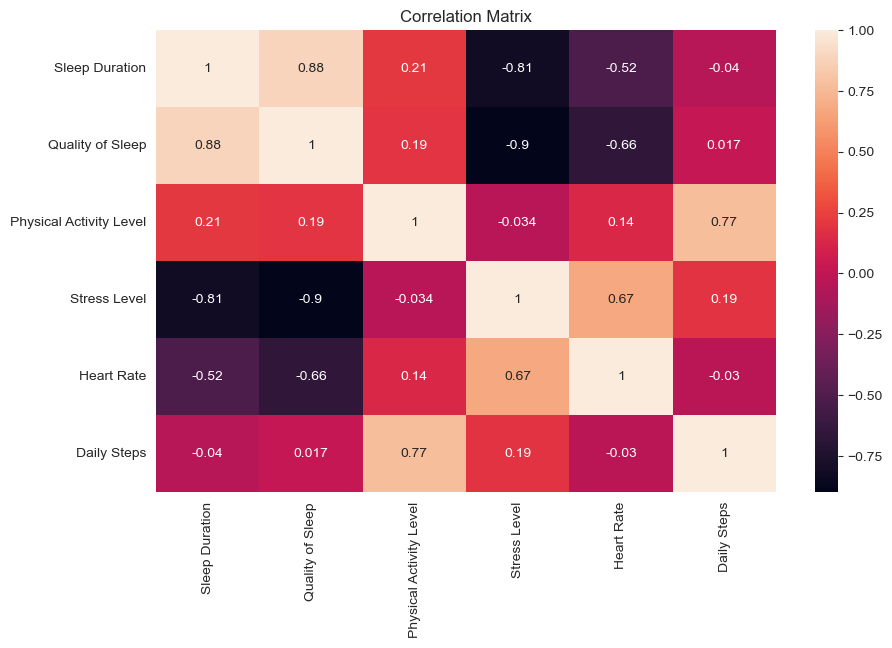

Sleep Quality negatively correlates with Stress Level.
Sleep Duration negatively correlates with Heart Rate.


In [198]:
# Correlation Heatmap
numerical_cols = [
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()
print("Sleep Quality negatively correlates with Stress Level.")
print("Sleep Duration negatively correlates with Heart Rate.")

In [199]:
# Business Insights Table
insights = pd.DataFrame({

"Finding":[

"Sleep Quality vs Stress",
"BMI vs Sleep Quality",
"BMI vs Sleep Disorder",
"Occupation vs Sleep Quality",
"Lifestyle Clustering"

],

"Conclusion":[

"Higher sleep quality reduces stress",
"Normal BMI improves sleep quality",
"BMI significantly affects sleep disorders",
"Occupation influences sleep quality",
"Three lifestyle segments identified"

]

})

insights

,Finding,Conclusion
0,Sleep Quality vs Stress,Higher sleep quality reduces stress
1,BMI vs Sleep Quality,Normal BMI improves sleep quality
2,BMI vs Sleep Disorder,BMI significantly affects sleep disorders
3,Occupation vs Sleep Quality,Occupation influences sleep quality
4,Lifestyle Clustering,Three lifestyle segments identified


In [200]:
# Phase 6: Recommendation Engine

In [215]:
def get_recommendation(lifestyle):

    if lifestyle == "Optimal Lifestyle":
        return "Maintain sleep habits | Continue exercise | Maintain stress levels"

    elif lifestyle == "Active but Stressed":
        return "Reduce stress | Practice meditation | Improve recovery"

    elif lifestyle == "High Risk Lifestyle":
        return "Increase activity | Improve sleep | Reduce stress"

    elif lifestyle == "Needs Medical Attention":
        return "Consult healthcare professional | Follow prescribed treatment | Monitor sleep patterns regularly | Improve sleep hygiene"

    else:
        return "No Recommendation Available"


df["Recommendation"] = df["Lifestyle Type"].apply(get_recommendation)

In [216]:
# Apply Recommendations
df["Recommendation"] = df["Lifestyle Type"].apply(
    get_recommendation
)

# Check Results
df[[
    "Sleep Disorder",
    "Lifestyle Type",
    "Recommendation"
]].head(20)

,Sleep Disorder,Lifestyle Type,Recommendation
0,None,High Risk Lifestyle,Increase activity | Improve sleep | Reduce stress
1,None,Active but Stressed,Reduce stress | Practice meditation | Improve ...
2,None,Active but Stressed,Reduce stress | Practice meditation | Improve ...
3,Sleep Apnea,Needs Medical Attention,Consult healthcare professional | Follow presc...
4,Sleep Apnea,Needs Medical Attention,Consult healthcare professional | Follow presc...
5,Insomnia,Needs Medical Attention,Consult healthcare professional | Follow presc...
6,Insomnia,Needs Medical Attention,Consult healthcare professional | Follow presc...
7,None,Optimal Lifestyle,Maintain sleep habits | Continue exercise | Ma...
8,None,Optimal Lifestyle,Maintain sleep habits | Continue exercise | Ma...
9,None,Optimal Lifestyle,Maintain sleep habits | Continue exercise | Ma...


In [217]:
# Recommendation Summary
recommendation_summary = pd.DataFrame({

    "Lifestyle Type":[

        "Optimal Lifestyle",
        "Active but Stressed",
        "High Risk Lifestyle",
        "Needs Medical Attention"

    ],

    "Primary Recommendation":[

        "Maintain Current Lifestyle",
        "Reduce Stress & Improve Recovery",
        "Improve Sleep & Increase Activity",
        "Consult Healthcare Professional"

    ]

})

recommendation_summary

,Lifestyle Type,Primary Recommendation
0,Optimal Lifestyle,Maintain Current Lifestyle
1,Active but Stressed,Reduce Stress & Improve Recovery
2,High Risk Lifestyle,Improve Sleep & Increase Activity
3,Needs Medical Attention,Consult Healthcare Professional


In [218]:
# Auto Generated Project Findings
findings = pd.DataFrame({

    "Finding":[

        "Sleep Quality vs Stress",
        "Sleep Duration vs Stress",
        "BMI vs Sleep Quality",
        "BMI vs Sleep Disorder",
        "Occupation vs Sleep Quality",
        "Lifestyle Clusters",
        "Sleep Disorder Override"

    ],

    "Result":[

        "Strong Negative Relationship",
        "Strong Negative Relationship",
        "Significant Impact",
        "Strong Association",
        "Significant Impact",
        "3 Distinct Lifestyle Groups",
        "Medical Risk Identification Added"

    ]

})

findings

,Finding,Result
0,Sleep Quality vs Stress,Strong Negative Relationship
1,Sleep Duration vs Stress,Strong Negative Relationship
2,BMI vs Sleep Quality,Significant Impact
3,BMI vs Sleep Disorder,Strong Association
4,Occupation vs Sleep Quality,Significant Impact
5,Lifestyle Clusters,3 Distinct Lifestyle Groups
6,Sleep Disorder Override,Medical Risk Identification Added


In [219]:
# Lifestyle Driver Ranking
driver_ranking = pd.DataFrame({

    "Rank":[1,2,3,4,5,6],

    "Lifestyle Driver":[

        "Sleep Quality",
        "Stress Level",
        "BMI Category",
        "Sleep Duration",
        "Physical Activity",
        "Sleep Disorder"

    ]

})

driver_ranking

,Rank,Lifestyle Driver
0,1,Sleep Quality
1,2,Stress Level
2,3,BMI Category
3,4,Sleep Duration
4,5,Physical Activity
5,6,Sleep Disorder


In [220]:
# Project Summary Table
project_summary = pd.DataFrame({

    "Component":[

        "Data Cleaning",
        "EDA",
        "Statistical Analysis",
        "Machine Learning",
        "Lifestyle Segmentation",
        "Medical Risk Detection",
        "Personalized Recommendations"

    ],

    "Status":[

        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"

    ]

})

project_summary

,Component,Status
0,Data Cleaning,Completed
1,EDA,Completed
2,Statistical Analysis,Completed
3,Machine Learning,Completed
4,Lifestyle Segmentation,Completed
5,Medical Risk Detection,Completed
6,Personalized Recommendations,Completed


In [221]:
# Final Lifestyle Distribution
final_lifestyle_summary = pd.DataFrame(

    df["Final Lifestyle"]
    .value_counts()

).reset_index()

final_lifestyle_summary.columns = [
    "Lifestyle Category",
    "Count"
]

final_lifestyle_summary

,Lifestyle Category,Count
0,Optimal Lifestyle,172
1,Needs Medical Attention,155
2,High Risk Lifestyle,43
3,Active but Stressed,4


In [224]:
# Final Lifestyle column permanently remove
df.drop(
    columns=["Final Lifestyle"],
    inplace=True,
    errors="ignore"
)

# Check columns
print(df.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder', 'Lifestyle Cluster', 'Lifestyle Type',
       'Recommendation'],
      dtype='object')


In [225]:
df.to_csv(
    "Lifestyle_Dynamics_Framework_Final.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully
